In [11]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [12]:
df=pd.read_csv("DiwaliSales.csv")

In [18]:
df.shape

(11251, 13)

In [38]:
#Total number of orders
orders=df["Orders"].sum()
print("Total numbers of orders",orders)

Total numbers of orders 27981


In [42]:
#Total Amounts
amounts=df["Amount"].sum()
print("Total Amounts",amounts)

Total Amounts 106249129


In [14]:
df.head()

,User_ID,Cust_name,Product_ID,Gender,Age_Group,Age,Marital_Status,State,Zone,Occupation,Product_Category,Orders,Amount,Status,unnamed1
0,1002903,Sanskriti,P00125942,F,26-35,28,0,Maharashtra,Western,Healthcare,Auto,1,23952.0,NaN,NaN
1,1000732,Kartik,P00110942,F,26-35,35,1,Andhra�Pradesh,Southern,Govt,Auto,3,23934.0,NaN,NaN
2,1001990,Bindu,P00118542,F,26-35,35,1,Uttar Pradesh,Central,Automobile,Auto,3,23924.0,NaN,NaN
3,1001425,Sudevi,P00237842,M,0-17,16,0,Karnataka,Southern,Construction,Auto,2,23912.0,NaN,NaN
4,1000588,Joni,P00057942,M,26-35,28,1,Gujarat,Western,Food Processing,Auto,2,23877.0,NaN,NaN


In [15]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 11251 entries, 0 to 11250
Data columns (total 15 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   User_ID           11251 non-null  int64  
 1   Cust_name         11251 non-null  object 
 2   Product_ID        11251 non-null  object 
 3   Gender            11251 non-null  object 
 4   Age_Group         11251 non-null  object 
 5   Age               11251 non-null  int64  
 6   Marital_Status    11251 non-null  int64  
 7   State             11251 non-null  object 
 8   Zone              11251 non-null  object 
 9   Occupation        11251 non-null  object 
 10  Product_Category  11251 non-null  object 
 11  Orders            11251 non-null  int64  
 12  Amount            11239 non-null  float64
 13  Status            0 non-null      float64
 14  unnamed1          0 non-null      float64
dtypes: float64(3), int64(4), object(8)
memory usage: 1.3+ MB


In [16]:
df.drop(['Status', 'unnamed1'], axis=1, inplace=True)

In [17]:
pd.isnull(df).sum()

User_ID              0
Cust_name            0
Product_ID           0
Gender               0
Age_Group            0
Age                  0
Marital_Status       0
State                0
Zone                 0
Occupation           0
Product_Category     0
Orders               0
Amount              12
dtype: int64

In [19]:
df.dropna(inplace=True)

In [22]:
df['Amount']=df['Amount'].astype("int")

In [23]:
df['Amount'].dtypes

dtype('int64')

In [24]:
df.describe()

,User_ID,Age,Marital_Status,Orders,Amount
count,1.123900e+04,11239.000000,11239.000000,11239.000000,11239.000000
mean,1.003004e+06,35.410357,0.420055,2.489634,9453.610553
std,1.716039e+03,12.753866,0.493589,1.114967,5222.355168
min,1.000001e+06,12.000000,0.000000,1.000000,188.000000
25%,1.001492e+06,27.000000,0.000000,2.000000,5443.000000
50%,1.003064e+06,33.000000,0.000000,2.000000,8109.000000
75%,1.004426e+06,43.000000,1.000000,3.000000,12675.000000
max,1.006040e+06,92.000000,1.000000,4.000000,23952.000000


In [25]:
df[["Age", 'Orders',"Amount"]].describe()

,Age,Orders,Amount
count,11239.000000,11239.000000,11239.000000
mean,35.410357,2.489634,9453.610553
std,12.753866,1.114967,5222.355168
min,12.000000,1.000000,188.000000
25%,27.000000,2.000000,5443.000000
50%,33.000000,2.000000,8109.000000
75%,43.000000,3.000000,12675.000000
max,92.000000,4.000000,23952.000000


Text(0.5, 1.0, 'Male Vs Female')

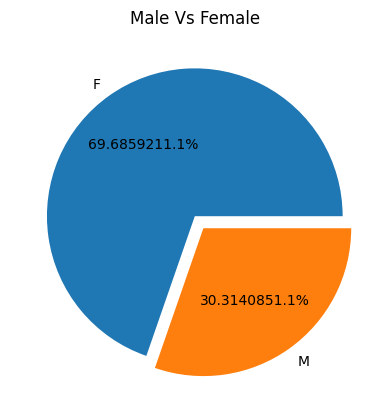

In [59]:
#Orders contribution of Male vs Female out of total ordes
gender_wise=df["Gender"].value_counts()
plt.pie(gender_wise, labels=gender_wise.index, autopct="%f1.1%%", explode=[0,0.1])
plt.title("Male Vs Female")

Text(0, 0.5, 'No. of Times of orders')

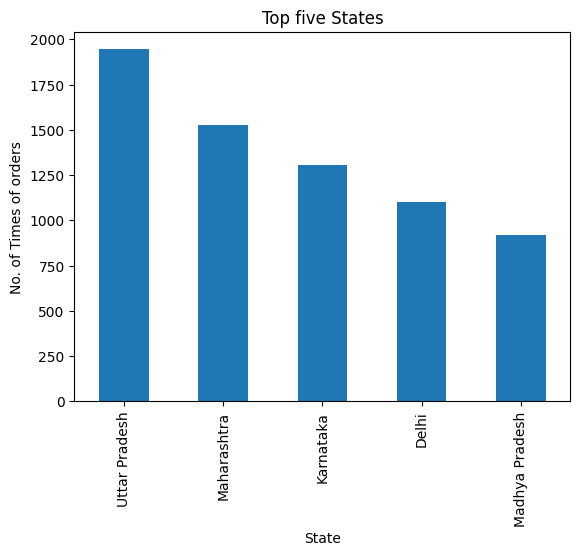

In [27]:
#Top states in term of highest number of ordes
top_5states=df['State'].value_counts().head(5)
top_5states.plot(kind='bar')
plt.title("Top five States")
plt.xlabel("State")
plt.ylabel("No. of Times of orders")

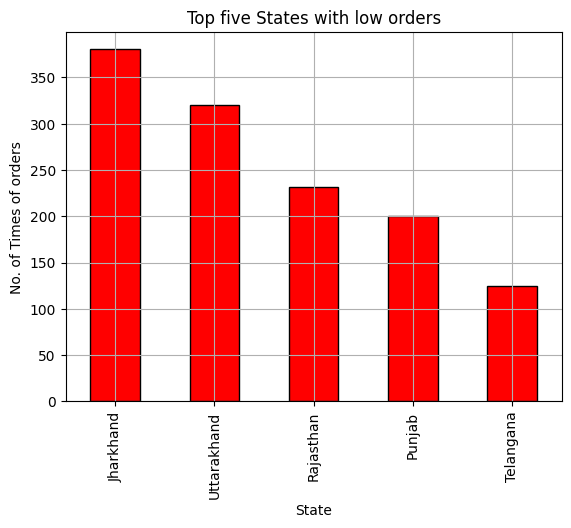

In [28]:
#Top five states in term of low no. of orders
low_5states=df["State"].value_counts().tail(5)
low_5states.plot(kind='bar', color='red', edgecolor='black')
plt.title("Top five States with low orders")
plt.xlabel("State")
plt.ylabel("No. of Times of orders")
plt.grid()

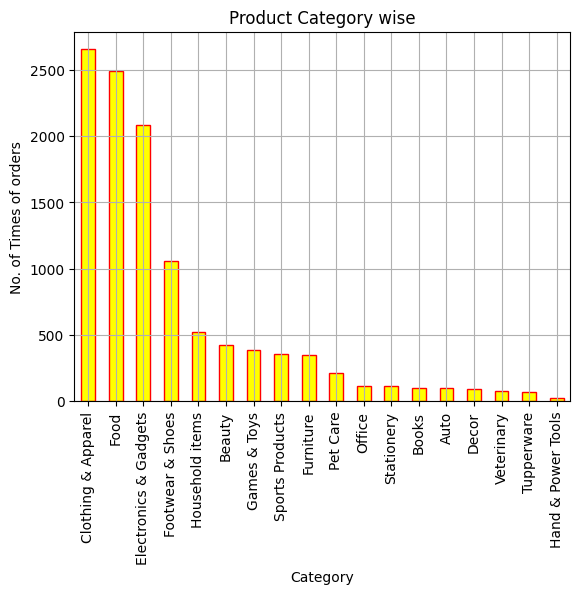

In [29]:
#Product category wise analysis
category=df["Product_Category"].value_counts()
category.plot(kind='bar', color='yellow', edgecolor="red")
plt.title("Product Category wise")
plt.xlabel("Category")
plt.ylabel("No. of Times of orders")
plt.grid()


Text(0.5, 1.0, 'Married Vs Unmarried')

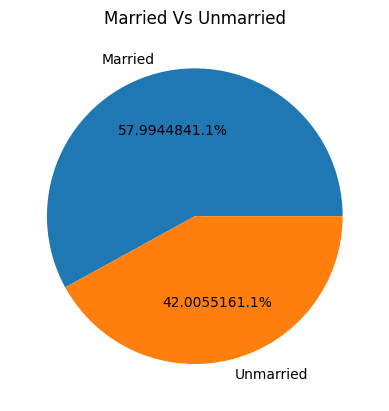

In [34]:
#Who buy more married or unmarried
married=df["Marital_Status"].value_counts()
plt.pie(married, labels=["Married", "Unmarried"], autopct="%f1.1%%")
plt.title("Married Vs Unmarried")

Text(0, 0.5, 'No. of Times of orders')

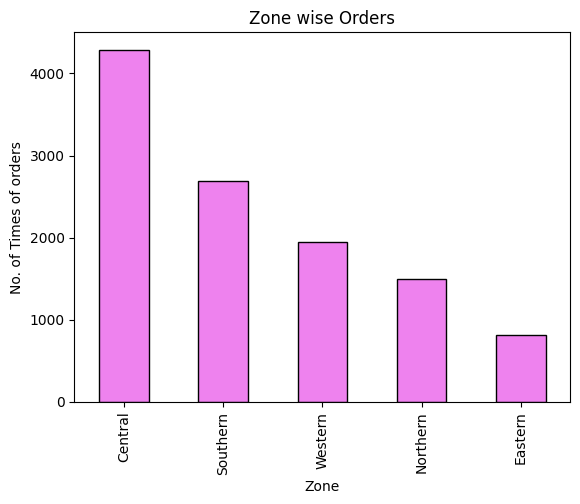

In [44]:
#Zone wise Orders
zone=df["Zone"].value_counts()
zone.plot(kind='bar', color='violet', edgecolor="black")
plt.title("Zone wise Orders")
plt.xlabel("Zone")
plt.ylabel("No. of Times of orders")


Text(0.5, 1.0, 'Order share customer Occupation wise')

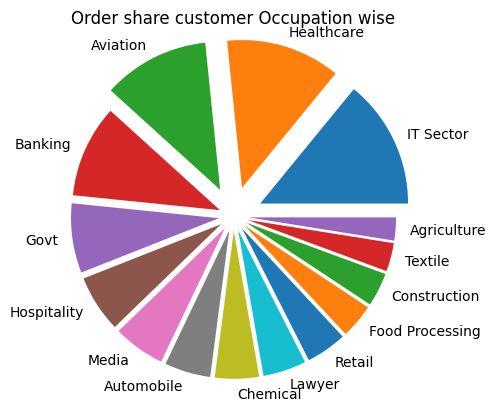

In [67]:
#Customers occupation
occupation_wise=df["Occupation"].value_counts()
plt.pie(occupation_wise, labels=occupation_wise.index, explode=[0.2,0.2,0.2,0.1,0.1,0.1,0.1,0.1,0.1,0.1,0.1,0.1,0.1,0.1,0.1])
plt.title("Order share customer Occupation wise")




Text(0, 0.5, 'No. of Times of orders')

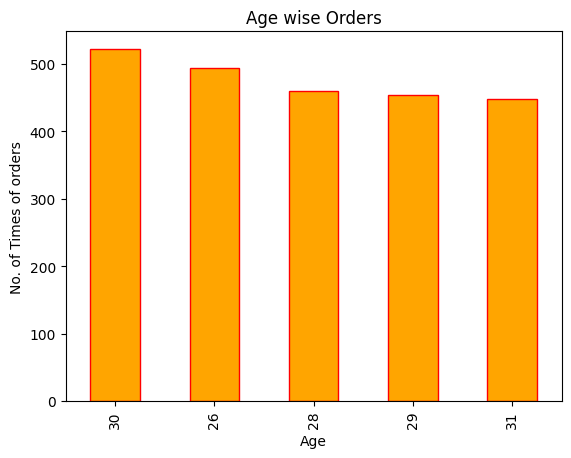

In [56]:
#Top age in term of highest order
age=df["Age"].value_counts().head(5)
age.plot(kind="bar", color="orange", edgecolor="red")
plt.title("Age wise Orders")
plt.xlabel("Age")
plt.ylabel("No. of Times of orders")




Text(0, 0.5, 'No. of Times of orders')

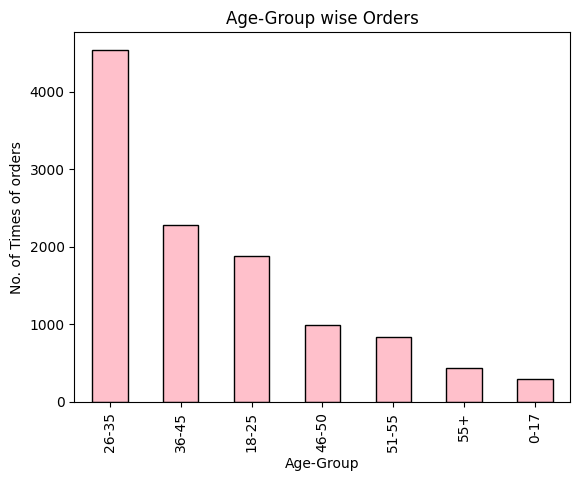

In [58]:
#Age-Group wise orders
age_group=df["Age_Group"].value_counts()
age_group.plot(kind="bar",color="pink", edgecolor="black")
plt.title("Age-Group wise Orders")
plt.xlabel("Age-Group")
plt.ylabel("No. of Times of orders")